In [1]:
import os
import datetime

import colorcet as cc
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import pandas as pd
from bokeh.plotting import figure, output_notebook, show
from bokeh.models import HoverTool, Title
from pathlib import Path
import folium
import rioxarray
import netCDF4

from shapely.geometry import box

from blackmarble.extract import bm_extract
from blackmarble.raster import bm_raster

import xarray as xr
import numpy as np


#Local Functions
import sys
sys.path.append('../src')
from ntl_functions import plot_NASA_NTL, filter_dataset_by_shapefile

%load_ext autoreload
%autoreload 2

plt.rcParams["figure.figsize"] = (18, 10)
pd.set_option('display.max_rows', 50)

# Data

In [2]:
#Somalia Shape File Downlaoded from. 
#https://gadm.org/download_country.html
gdf = gpd.read_file(
    "../data/Combined_Datasets/gadm41_SOM_1.json.zip"
)
#Somaliland SHP File
somaliland_shp = gdf[gdf["HASC_1"].isin(["SO.AW", "SO.WO", "SO.TO", "SO.SA", "SO.SO"])]

expanded_borders = somaliland_shp.dissolve().buffer(0.0027)
gdf_expanded = gpd.GeoDataFrame(geometry=expanded_borders)
gdf_expanded.set_crs(epsg=4326, inplace=True)

C:\Users\samsa\AppData\Local\Temp\ipykernel_11936\2290477033.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  expanded_borders = somaliland_shp.dissolve().buffer(0.0027)


,geometry
0,"MULTIPOLYGON (((43.24866 11.46341, 43.24862 11..."


In [3]:
#Primary Data Source
expanded_SL_VNP46A4_EY_2012_24 = xr.open_dataset("../data/NTL_Data_A4/expanded_SL_VNP46A4_EY_2012_24.nc")
expanded_SL_VNP46A4_EY_2012_24 = expanded_SL_VNP46A4_EY_2012_24.where(expanded_SL_VNP46A4_EY_2012_24 != 6553.5, 0)

logged_NTL = xr.where(
    expanded_SL_VNP46A4_EY_2012_24 > 0, 
    np.log(expanded_SL_VNP46A4_EY_2012_24), 
    0  # Assign 0 for non-positive values
)

C:\Users\samsa\anaconda3\Lib\site-packages\xarray\core\computation.py:761: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


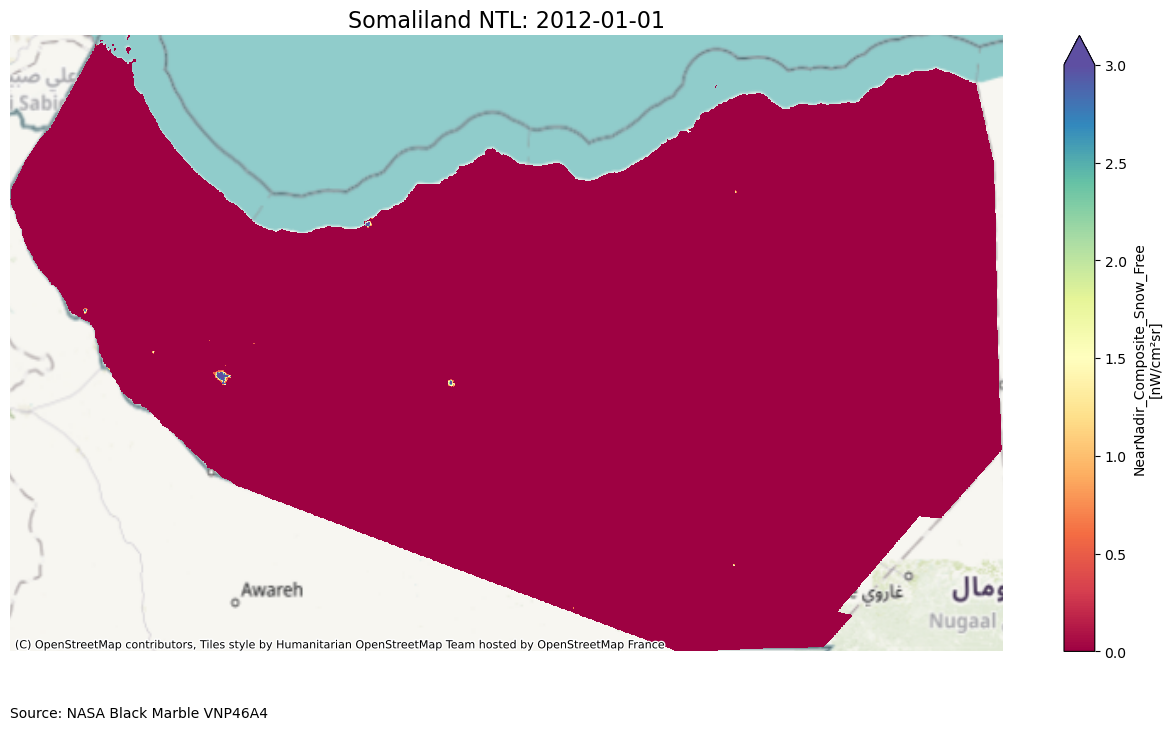

In [4]:
plot_NASA_NTL(expanded_SL_VNP46A4_EY_2012_24, gdf_expanded, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              robust = False, vmin=0, vmax=3)
plt.savefig(f'../output/Graphics/SL_Expanded_2012.png', dpi=300, bbox_inches='tight')  

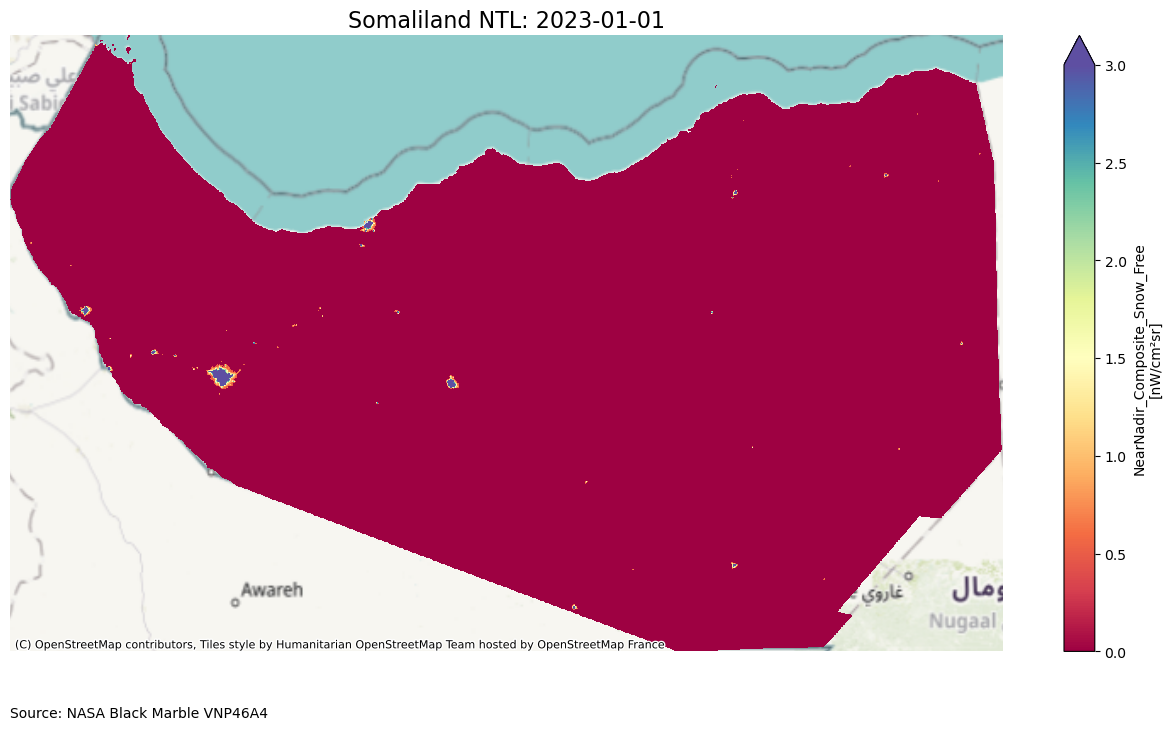

In [5]:
plot_NASA_NTL(expanded_SL_VNP46A4_EY_2012_24, gdf_expanded, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              robust = False, vmin=0, vmax=3)
plt.savefig(f'../output/Graphics/SL_Expanded_2023.png', dpi=300, bbox_inches='tight')  

In [16]:
somaliland_shp

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,SOM.1_1,SOM,Somalia,Awdal,Adal|Adel,NA,Gobolka,Region,NA,SO.AW,SO-AW,"MULTIPOLYGON (((43.4626 11.3535, 43.4676 11.35..."
12,SOM.13_1,SOM,Somalia,Sanaag,Sanag,NA,Gobolka,Region,NA,SO.SA,NA,"MULTIPOLYGON (((46.84 9.42, 46.01 10.08, 46.03..."
15,SOM.16_1,SOM,Somalia,Sool,NA,NA,Gobolka,Region,NA,SO.SO,SO-SO,"MULTIPOLYGON (((47.25 7.9923, 47.0088 7.9854, ..."
16,SOM.17_1,SOM,Somalia,Togdheer,Tog-Dheer|Togdheer|Togder,NA,Gobolka,Region,NA,SO.TO,SO-TO,"MULTIPOLYGON (((46.7358 8.0703, 45.6208 8.4429..."
17,SOM.18_1,SOM,Somalia,WoqooyiGalbeed,North-West|W.Galbeed|WoqooyiG,NA,Gobolka,Region,NA,SO.WO,SO-WO,"MULTIPOLYGON (((43.9585 9.065, 43.9123 9.1027,..."


(42.385935, 49.398765, 7.8086, 11.691600000000001)

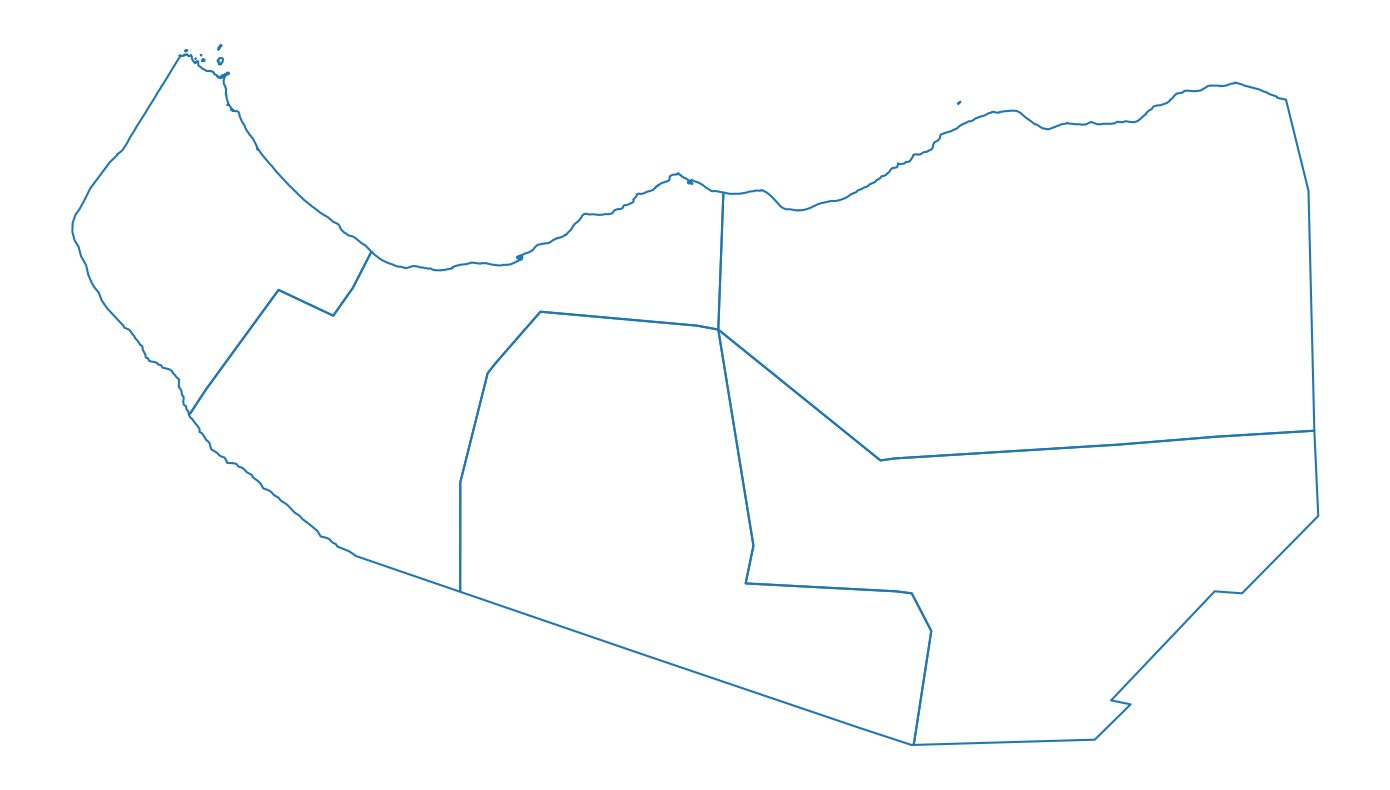

In [15]:
somaliland_shp.boundary.plot()
plt.axis("off")

In [6]:
expanded_SL_VNP46A4_EY_2012_24

<xarray.Dataset>
Dimensions:                        (time: 12, y: 848, x: 1532)
Coordinates:
  * x                              (x) float64 42.7 42.71 42.71 ... 49.08 49.08
  * y                              (y) float64 11.51 11.51 11.51 ... 7.99 7.986
  * time                           (time) datetime64[ns] 2012-01-01 ... 2023-...
Data variables:
    NearNadir_Composite_Snow_Free  (time, y, x) float64 nan nan nan ... nan nan
Attributes: (12/40)
    AlgorithmType:                     b'SCI'
    AlgorithmVersion:                  b'NPP_PR46A3 2.0.0'
    Conventions:                       b'CF-1.6'
    DataResolution:                    b'15 arc second'
    DayNightFlag:                      b'Night'
    HorizontalTileNumber:              b'22'
    ...                                ...
    NorthBoundingCoord:                20.0
    publisher_email:                   b'modis-ops@lists.nasa.gov'
    publisher_name:                    b'LAADS'
    publisher_url:                     b'https://ladsweb.modaps.eosdis.nasa.gov'
    SouthBoundingCoord:                10.0
    WestBoundingCoord:                 40.0